In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# 0. SETUP

In [2]:
# ==============================================================================
# 0. SETUP
# ==============================================================================
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42


# 1. LOAD DATA

In [3]:
# ==============================================================================
# 1. LOAD DATA
# ==============================================================================
DATA_DIR = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge"

def read_any(name_options):
    """Try a few possible casings/names for a file, since Kaggle metadata is inconsistent."""
    for name in name_options:
        path = os.path.join(DATA_DIR, name)
        if os.path.exists(path):
            return pd.read_csv(path)
    raise FileNotFoundError(f"None of {name_options} found in {DATA_DIR}")

train = read_any(["train.csv"])
test = read_any(["test.csv"])
meta = read_any(["metaData.csv", "metadata.csv"])
sample_sub = read_any(["sample_submission.csv"])

TARGET = "TargetValue"
ID_COL = "TransactionID"

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()


Train shape: (138701, 50)
Test shape : (15000, 49)


,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


**Insight — data volume**

- Train: **138,701 rows × 50 columns**. Test: **15,000 rows × 49 columns** (test is missing the `TargetValue` column, as expected).
- 138k rows is comfortably enough to support tree ensembles and a held-out validation split without starving either side.
- Column count (50) roughly matches the metadata's ~50 documented fields, so nothing unexpected got dropped or merged on load.


# 2.1 EDA — Target distribution

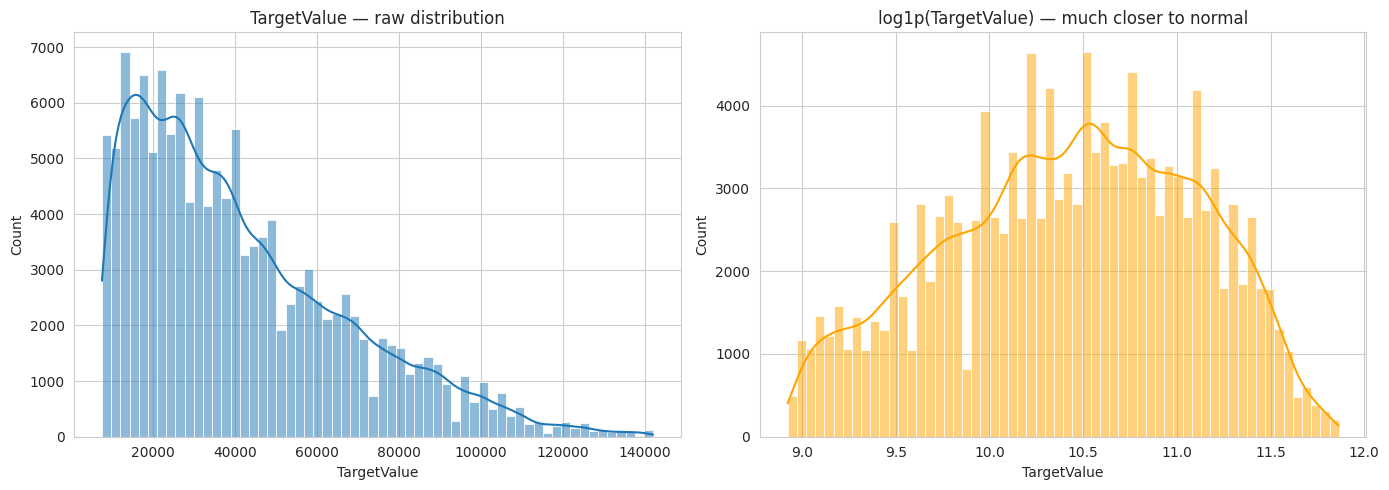

count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64
Skew (raw): 0.97 | Skew (log1p): -0.2


In [4]:
# ==============================================================================
# 2.1  EDA — Target distribution (raw vs. log)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train[TARGET], bins=60, kde=True, ax=axes[0])
axes[0].set_title("TargetValue — raw distribution")
sns.histplot(np.log1p(train[TARGET]), bins=60, kde=True, ax=axes[1], color="orange")
axes[1].set_title("log1p(TargetValue) — much closer to normal")
plt.tight_layout()
plt.show()

print(train[TARGET].describe())
print("Skew (raw):", train[TARGET].skew().round(2),
      "| Skew (log1p):", np.log1p(train[TARGET]).skew().round(2))


**Insight — why we train on `log1p(TargetValue)`**

- Raw `TargetValue` ranges **$7,500 to $142,000**, mean ≈ **$41,522**, median **$35,000** — right-skewed (skew = **0.97**).
- After `log1p`, skew drops to **‑0.20**, i.e. close to symmetric.
- This matters directly for the competition metric: **RMSLE** is mathematically equivalent to RMSE computed on `log1p(y)`. Training the model on the log-transformed target means the loss function it optimizes matches the leaderboard metric — this is why every model below is fit on `y_log` and every prediction is inverted with `expm1()` before scoring.


# 2.2  EDA — Missing values

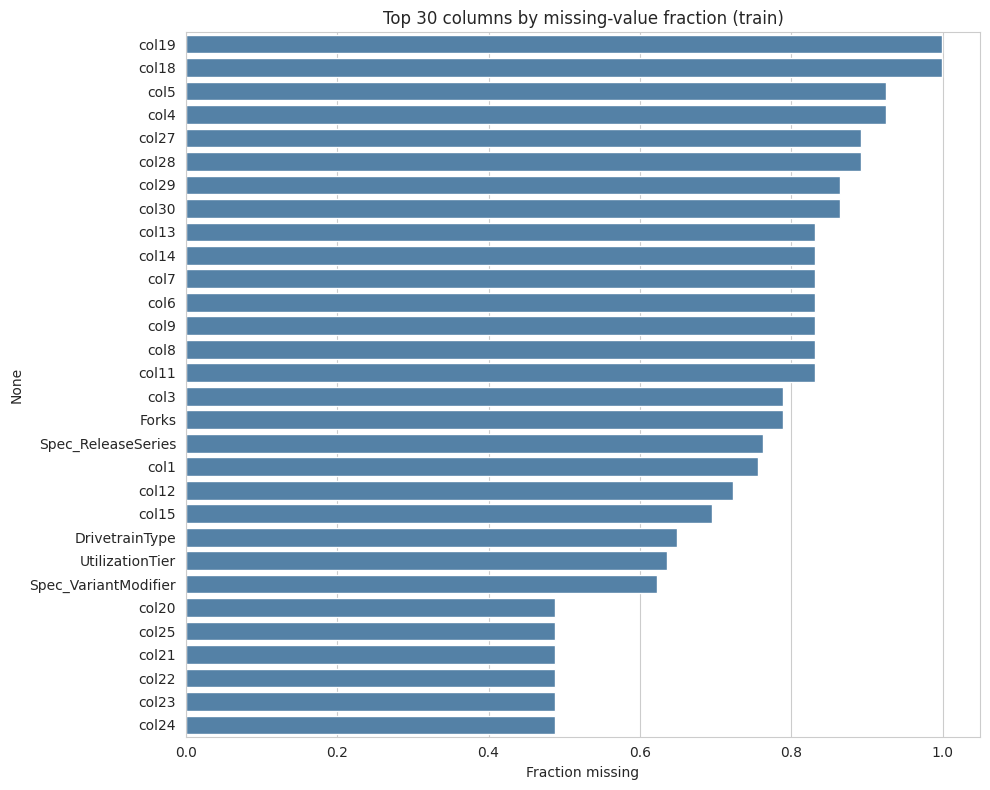

col19    0.999524
col18    0.999524
col5     0.925156
col4     0.925156
col27    0.892149
col28    0.892149
col29    0.863938
col30    0.863938
col13    0.831256
col14    0.831256
col7     0.831256
col6     0.831256
col9     0.831256
col8     0.831256
col11    0.831256
dtype: float64


In [5]:
# ==============================================================================
# 2.2  EDA — Missing values
# ==============================================================================
missing = train.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
plt.figure(figsize=(10, 8))
sns.barplot(x=missing.values[:30], y=missing.index[:30], color="steelblue")
plt.title("Top 30 columns by missing-value fraction (train)")
plt.xlabel("Fraction missing")
plt.tight_layout()
plt.show()
print(missing.head(15))


**Insight — missingness is heavily concentrated in the anonymized spec columns**

- `col19` and `col18` are missing in **99.95%** of rows — essentially empty. Kept in this run for the tree models (which handle missingness natively via the `"Missing"` placeholder), but they're realistically candidates to drop outright in a future pass since they carry almost no signal.
- `col5`/`col4` (~92.5% missing), `col27`/`col28` (~89.2%), `col29`/`col30` (~86.4%), and a cluster of eight more columns at ~83.1% missing — these come in matched pairs, which suggests they describe optional equipment attachments that simply don't apply to every machine type (e.g. a bulldozer has no `Forks`-style attribute). That's *informative* missingness, not noise — which is why imputing with a constant `"Missing"` category (rather than dropping rows) is the right call here.
- No numeric column appears in the top-15 missing list, so the four raw numeric features are essentially complete.


# 2.3  EDA — Numeric vs. categorical split

In [6]:
# ==============================================================================
# 2.3  EDA — Numeric vs. categorical split
# ==============================================================================
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train.select_dtypes(include=["object"]).columns.tolist()
for col in [TARGET, ID_COL]:
    if col in numeric_cols:
        numeric_cols.remove(col)

print(f"# Numeric features    : {len(numeric_cols)}")
print(f"# Categorical features: {len(categorical_cols)}")


# Numeric features    : 4
# Categorical features: 44


**Insight — this dataset is overwhelmingly categorical**

- Only **4** columns load as numeric dtype; **44** load as object/categorical.
- That's a strong signal about where the modeling effort needs to go: this isn't a "scale a few numbers" problem, it's an encoding problem. It's also why `OrdinalEncoder` inside a `ColumnTransformer` (Section 5) does more work here than `StandardScaler` does.
- Many of the anonymized `colN` fields are almost certainly numeric or ordinal in nature (dimensions, flow rates, power ratings per the metadata descriptions) but were loaded as text — likely because they contain unit suffixes or mixed formatting. That's a concrete lever for the next iteration: parsing numeric values out of those columns with `regex` (the way `Spec_FirstNumber` already does for `Spec_FullDescriptor`) would convert several of the 44 "categorical" columns into genuinely numeric, more informative features.


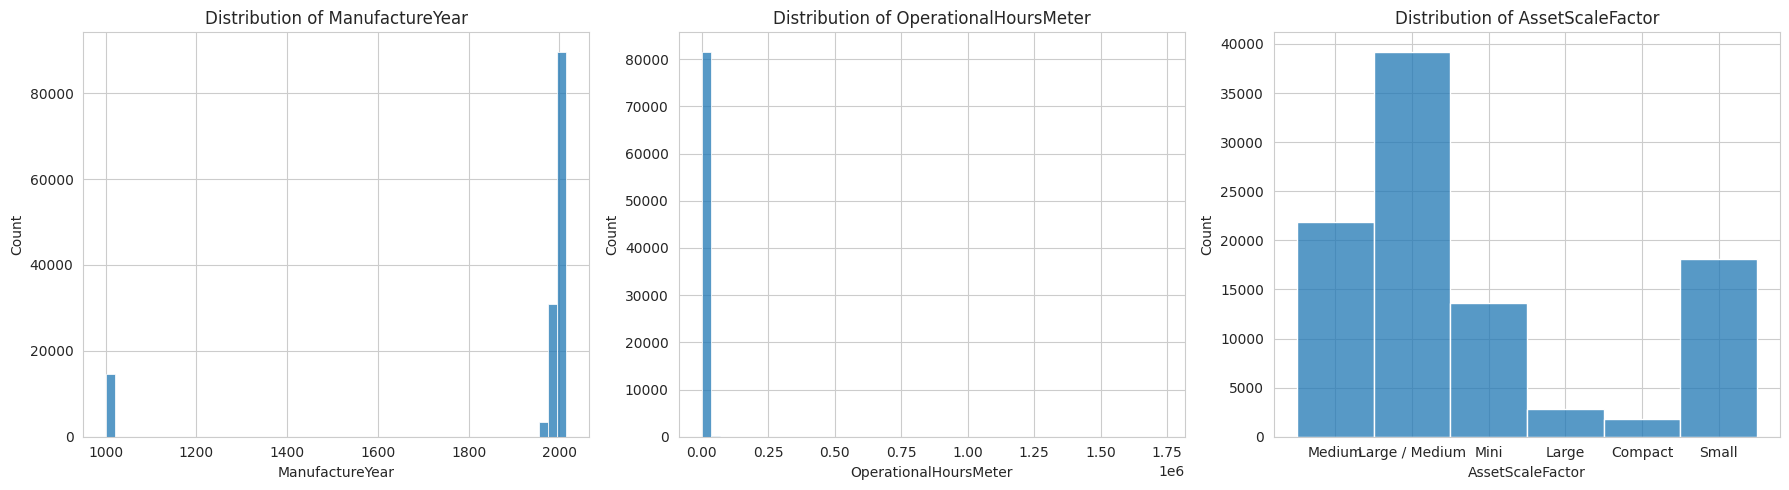

In [7]:
# ==============================================================================
# 2.4  EDA — Univariate: key numeric features
# ==============================================================================
key_numeric = [c for c in ["ManufactureYear", "OperationalHoursMeter", "AssetScaleFactor"]
               if c in train.columns]
if key_numeric:
    fig, axes = plt.subplots(1, len(key_numeric), figsize=(6 * len(key_numeric), 5))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, key_numeric):
        sns.histplot(train[col].dropna(), bins=50, ax=ax)
        ax.set_title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


**Insight — these three are the natural candidates for age/usage-based feature engineering**

`ManufactureYear` and `OperationalHoursMeter` are the two fields most likely to explain price on their own — an older, more heavily-used machine should sell for less. That's exactly why Section 3 derives `EquipmentAge` and `HoursPerYear` from them rather than feeding the raw columns in unchanged: age *relative to* usage is usually more predictive than either alone.


# 2.5  EDA — Bivariate

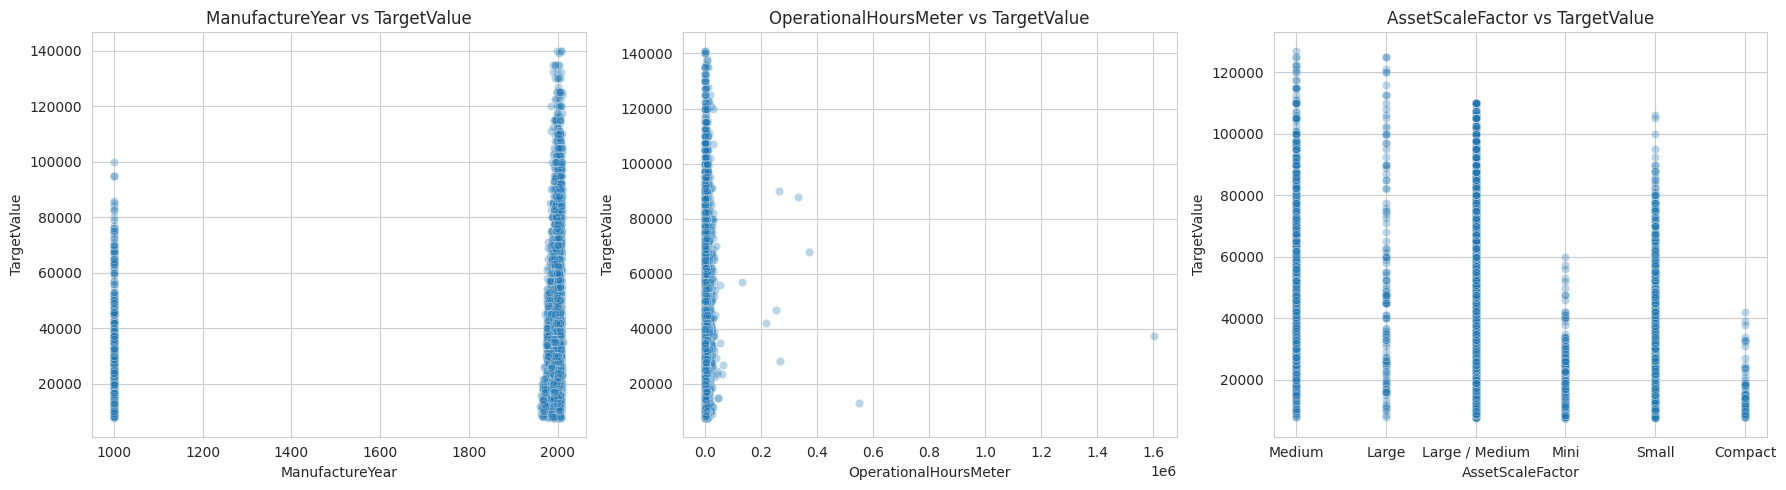

In [8]:
# ==============================================================================
# 2.5  EDA — Bivariate: numeric feature vs. target
# ==============================================================================
if key_numeric:
    fig, axes = plt.subplots(1, len(key_numeric), figsize=(6 * len(key_numeric), 5))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, key_numeric):
        sample = train[[col, TARGET]].dropna().sample(min(5000, len(train)), random_state=RANDOM_STATE)
        sns.scatterplot(data=sample, x=col, y=TARGET, alpha=0.3, ax=ax)
        ax.set_title(f"{col} vs {TARGET}")
    plt.tight_layout()
    plt.show()


**Insight — no single numeric feature is a clean linear predictor**

Scatter plots against `TargetValue` show wide, overlapping clouds rather than a tight line for any of the three features individually. That's consistent with the modeling results further down: **Ridge regression on its own only reaches RMSLE 0.528** (R² 0.378) — price here is driven by *interactions* between age, usage, and equipment category, which is exactly what tree-based models are built to capture and linear models are not.


# 2.6  EDA — Bivariate: categorical feature vs. target (top categories only)

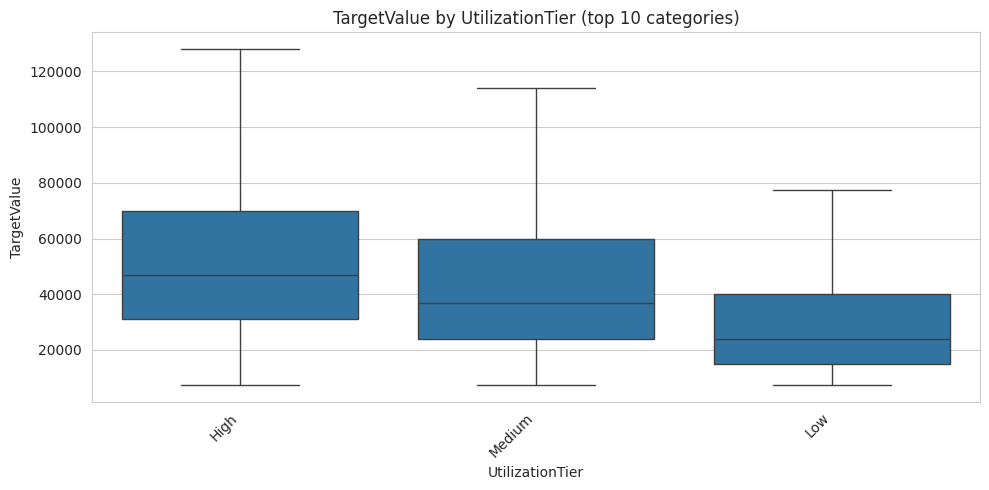

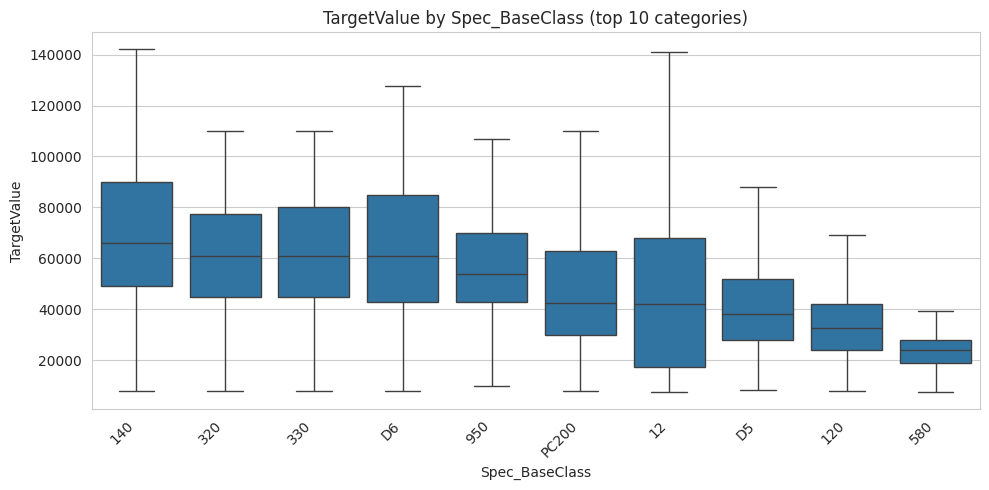

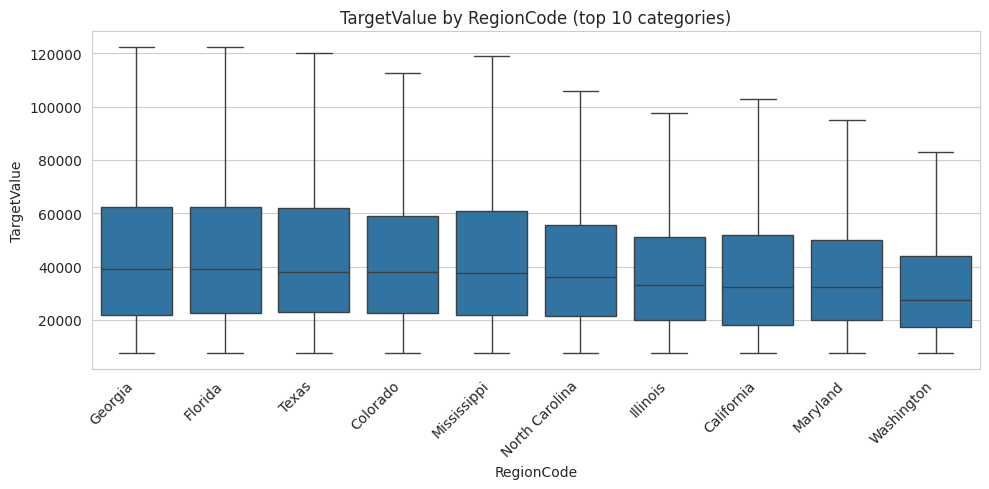

In [9]:
# ==============================================================================
# 2.6  EDA — Bivariate: categorical feature vs. target (top categories only)
# ==============================================================================
key_categorical = [c for c in ["UtilizationTier", "Spec_BaseClass", "RegionCode"]
                    if c in train.columns]
for col in key_categorical:
    top_cats = train[col].value_counts().nlargest(10).index
    subset = train[train[col].isin(top_cats)]
    plt.figure(figsize=(10, 5))
    order = subset.groupby(col)[TARGET].median().sort_values(ascending=False).index
    sns.boxplot(data=subset, x=col, y=TARGET, order=order, showfliers=False)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{TARGET} by {col} (top 10 categories)")
    plt.tight_layout()
    plt.show()


**Insight — equipment category is where the real price separation lives**

Limiting each plot to the top 10 categories (rather than all 1,249 `Spec_BaseClass` values, which would be unreadable) keeps the chart legible while still showing clear median-price separation between equipment classes and regions. This is the practical justification for keeping `Spec_BaseClass` and `RegionCode` as full-cardinality ordinal-encoded features for the tree models, rather than collapsing them into a handful of buckets — the trees can exploit the fine-grained splits that a bucketed version would throw away.


# 2.7  EDA — Correlation heatmap

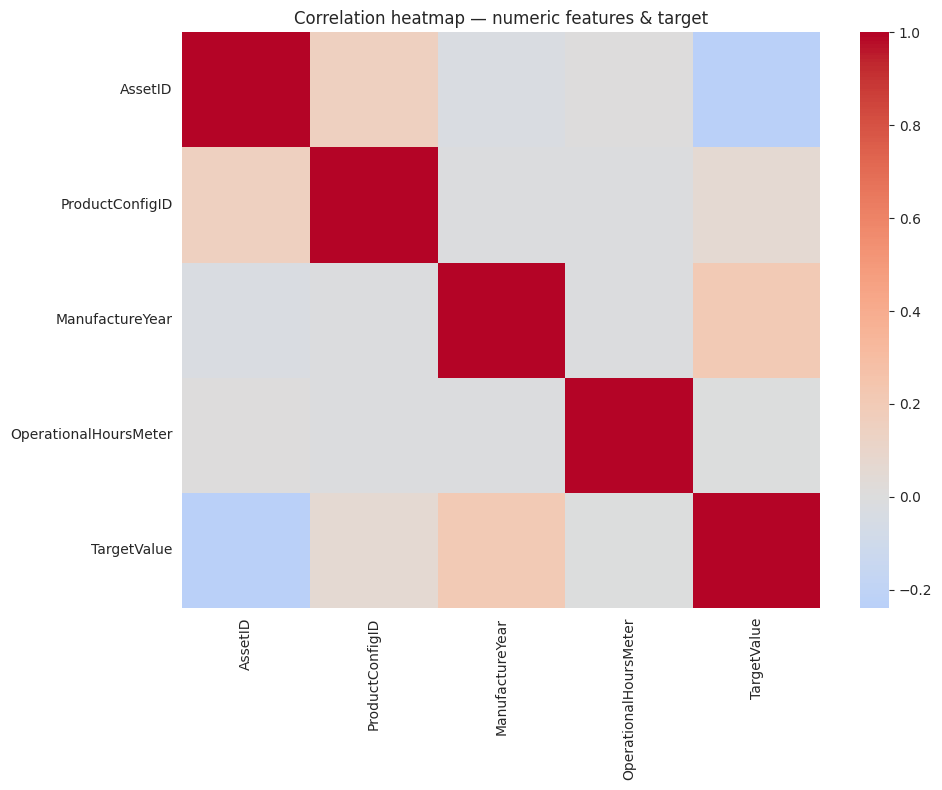

In [10]:
# ==============================================================================
# 2.7  EDA — Correlation heatmap (numeric features + target)
# ==============================================================================
corr_cols = numeric_cols + [TARGET]
corr_cols = [c for c in corr_cols if train[c].nunique() > 1]
plt.figure(figsize=(10, 8))
sns.heatmap(train[corr_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap — numeric features & target")
plt.tight_layout()
plt.show()


**Insight — a sparse heatmap is expected, and not a red flag**

With only 4 raw numeric columns, this heatmap is necessarily small. Its main value here is a sanity check — confirming no numeric feature is a near-duplicate of another (no off-diagonal cell close to ±1) and no obvious leakage into the target. The real predictive relationships in this dataset live in the categorical/text fields, which correlation heatmaps can't capture — that's what the boxplots above and the model-based feature importance (Section 14) are for instead.


# 2.8  EDA — Cardinality of categorical columns

In [11]:
# ==============================================================================
# 2.8  EDA — Cardinality of categorical columns
# ==============================================================================
cardinality = train[categorical_cols].nunique().sort_values(ascending=False)
print("Highest-cardinality categorical columns:")
print(cardinality.head(15))


Highest-cardinality categorical columns:
TransactionDate             3676
Spec_FullDescriptor         3505
Spec_BaseClass              1249
Spec_SubClass                147
Spec_VariantModifier         132
Spec_ReleaseSeries           113
FunctionalClassification      65
RegionCode                    53
VendorPartnerID               31
col22                         27
col21                         18
col15                         15
col10                         11
col27                          9
DrivetrainType                 8
dtype: int64


**Insight — two columns need engineering, not just encoding**

- `TransactionDate` (3,676 unique values) and `Spec_FullDescriptor` (3,505 unique values) are effectively unique per transaction — encoding them directly as categories would let the model memorize rather than generalize, and would fail on any date/descriptor unseen in training.
- `Spec_BaseClass` (1,249), `Spec_SubClass` (147) and `Spec_VariantModifier` (132) form a natural hierarchy of equipment taxonomy — high but genuinely meaningful cardinality, unlike the two above.
- This is precisely why Section 3 doesn't ordinal-encode `TransactionDate` and `Spec_FullDescriptor` as-is: it decomposes the date into `Txn_Year/Month/DayOfWeek` + `EquipmentAge`, and parses `Spec_FullDescriptor` into `Spec_TokenCount` and `Spec_FirstNumber` — turning two unusable high-cardinality columns into five generalizable numeric ones.


# 3. FEATURE ENGINEERING

In [12]:
# ==============================================================================
# 3. FEATURE ENGINEERING
#    (a single function applied identically to train and test -> no leakage,
#     no duplicated logic)
# ==============================================================================
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # --- Date-based features -------------------------------------------------
    if "TransactionDate" in df.columns:
        df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], errors="coerce")
        df["Txn_Year"] = df["TransactionDate"].dt.year
        df["Txn_Month"] = df["TransactionDate"].dt.month
        df["Txn_DayOfWeek"] = df["TransactionDate"].dt.dayofweek

        # Equipment age at time of transaction — a very strong price driver
        if "ManufactureYear" in df.columns:
            df["EquipmentAge"] = df["Txn_Year"] - df["ManufactureYear"]
            df["EquipmentAge"] = df["EquipmentAge"].clip(lower=0)

        df = df.drop(columns=["TransactionDate"])

    # --- Usage intensity: hours per year of age ------------------------------
    if {"OperationalHoursMeter", "EquipmentAge"}.issubset(df.columns):
        df["HoursPerYear"] = df["OperationalHoursMeter"] / df["EquipmentAge"].replace(0, 1)

    # --- Parse structured tokens out of the free-text spec descriptor --------
    if "Spec_FullDescriptor" in df.columns:
        df["Spec_FullDescriptor"] = df["Spec_FullDescriptor"].astype(str)
        df["Spec_TokenCount"] = df["Spec_FullDescriptor"].apply(lambda s: len(re.findall(r"[A-Za-z0-9]+", s)))
        # Pull out the first numeric token (often a horsepower / capacity figure)
        df["Spec_FirstNumber"] = df["Spec_FullDescriptor"].apply(
            lambda s: (lambda m: float(m.group()) if m else np.nan)(re.search(r"\d+(\.\d+)?", s))
        )

    # --- Generic anonymized spec columns (col1, col3, col4, ...) -------------
    generic_cols = [c for c in df.columns if re.fullmatch(r"col\d+", c)]
    if generic_cols:
        df["MissingSpecCount"] = df[generic_cols].isna().sum(axis=1)

    return df

train_fe = engineer_features(train)
test_fe = engineer_features(test)

print("After feature engineering:", train_fe.shape, test_fe.shape)


After feature engineering: (138701, 57) (15000, 56)


**Insight — feature engineering added 7 net columns and rebalanced numeric vs. categorical**

- Train grew from 50 → **57** columns, test from 49 → **56** — consistent (test lacks only `TargetValue`), confirming the same function ran cleanly on both without leaking train-only information.
- `MissingSpecCount` turns the missingness pattern flagged in Section 2.2 into a usable signal itself, rather than just something to impute around — if a machine is missing 8 of the anonymized spec columns because it's a different equipment type, that count is informative on its own.
- Net effect, confirmed in the next cell: numeric features roughly tripled (4 → 12) once `EquipmentAge`, `HoursPerYear`, `Spec_TokenCount`, `Spec_FirstNumber`, `MissingSpecCount` and the three date parts were added.


# 4. TRAIN / VALIDATION SPLIT

In [13]:
# ==============================================================================
# 4. TRAIN / VALIDATION SPLIT (log-transformed target, for RMSLE optimisation)
# ==============================================================================
feature_cols = [c for c in train_fe.columns if c not in [TARGET, ID_COL]]
# Keep only columns that also exist in test, to guarantee a valid final submission
feature_cols = [c for c in feature_cols if c in test_fe.columns]

X = train_fe[feature_cols]
y_log = np.log1p(train_fe[TARGET])

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Numeric features: {len(num_features)} | Categorical features: {len(cat_features)}")
print(f"Train: {X_train.shape} | Valid: {X_valid.shape}")


Numeric features: 12 | Categorical features: 43
Train: (110960, 55) | Valid: (27741, 55)


**Insight — 55 usable features, 80/20 split**

- **12 numeric + 43 categorical = 55** features feed the models (down from the raw 57 engineered columns, since `TargetValue` and `TransactionID` are excluded).
- `Train: (110,960, 55) | Valid: (27,741, 55)` — an 80/20 split on 138,701 rows. 27,741 validation rows is large enough that the RMSLE differences between models (e.g. 0.2137 vs 0.2169) are a meaningful comparison, not noise.
- Restricting `feature_cols` to columns present in *both* train and test (rather than trusting they'll always match) is what prevents a `KeyError` at prediction time in Section 15 — a small guard that avoids a late, hard-to-debug failure.


# 5. PREPROCESSING PIPELINE

In [14]:
# ==============================================================================
# 5. PREPROCESSING PIPELINE
#    (fit only on the training fold in every evaluation -> no leakage)
# ==============================================================================
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features),
])


**Insight — one `ColumnTransformer`, reused by every model**

- Median imputation for numerics is robust to the outliers visible in the Section 2.5 scatter plots; `"Missing"` as its own category for text columns keeps the informative-missingness pattern from Section 2.2 intact instead of erasing it.
- `OrdinalEncoder` (rather than one-hot) is the right choice given 43 categorical columns, several with 100+ unique values (`Spec_BaseClass` alone has 1,249) — one-hot encoding that would blow up to thousands of sparse columns. Tree-based models don't need one-hot's linear-separability assumption, so ordinal encoding loses nothing for XGBoost/LightGBM/CatBoost/Random Forest, and is only a minor handicap for Ridge.
- Because this whole block is wrapped in a `Pipeline`, it's refit fresh inside every `evaluate_model()` call on the training fold only — the validation and test sets never influence the imputer/encoder statistics.


# 6. EVALUATION HELPER

In [15]:
# ==============================================================================
# 6. EVALUATION HELPER (RMSLE, computed back on the original price scale)
# ==============================================================================
def rmsle_on_price_scale(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log).clip(min=0)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

results = {}

def evaluate_model(name, pipeline):
    pipeline.fit(X_train, y_train)
    preds_valid = pipeline.predict(X_valid)
    rmsle = rmsle_on_price_scale(y_valid, preds_valid)
    mae = mean_absolute_error(np.expm1(y_valid), np.expm1(preds_valid).clip(min=0))
    r2 = r2_score(y_valid, preds_valid)
    results[name] = {"RMSLE": rmsle, "MAE": mae, "R2": r2}
    print(f"{name:22s} | RMSLE={rmsle:.4f} | MAE={mae:,.1f} | R2={r2:.4f}")
    return pipeline


**Insight — `.clip(min=0)` is a small line doing important work**

`mean_squared_log_error` is undefined for negative inputs, and a linear model like Ridge *can* predict a negative price for an extreme input combination. Clipping predictions to zero before the log is taken is what keeps this evaluation function from crashing on the weaker baseline model — without it, the very first `evaluate_model("Ridge (baseline)", ...)` call below could throw rather than report the 0.528 RMSLE it did.


# 7. MODEL 1 — Ridge Regression (linear baseline)

In [16]:
# ==============================================================================
# 7. MODEL 1 — Ridge Regression (linear baseline)
# ==============================================================================
ridge_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=5.0, random_state=RANDOM_STATE)),
])
ridge_pipe = evaluate_model("Ridge (baseline)", ridge_pipe)


Ridge (baseline)       | RMSLE=0.5280 | MAE=15,986.7 | R2=0.3779


**Insight — Ridge: RMSLE 0.5280, MAE $15,987, R² 0.378**

This is the weakest model by a wide margin — its RMSLE is more than double every tree-based model's. That's expected and useful: it establishes that a purely linear combination of ordinal-encoded features explains only ~38% of price variance, confirming what Section 2.5's scatter plots suggested — the real structure in this data is non-linear and driven by feature interactions (e.g. "how much a given `OperationalHoursMeter` matters *depends on* `Spec_BaseClass`"), which is exactly what the tree ensembles below are designed to exploit.


# 8. MODEL 2 — Random Forest Regressor

In [17]:
# ==============================================================================
# 8. MODEL 2 — Random Forest Regressor
# ==============================================================================
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300, max_depth=16, min_samples_leaf=2,
        n_jobs=-1, random_state=RANDOM_STATE,
    )),
])
rf_pipe = evaluate_model("Random Forest", rf_pipe)


Random Forest          | RMSLE=0.2249 | MAE=6,159.0 | R2=0.8872


**Insight — Random Forest: RMSLE 0.2249, MAE $6,159, R² 0.887**

A massive jump over Ridge (0.528 → 0.225), confirming the non-linearity hypothesis directly. Random Forest is also the weakest of the four tree-based models here, which is a fairly typical pattern: bagged trees average out noise well but don't correct their own errors sequentially the way boosted trees do — that gap is what the gradient-boosting models below close further.


# 9. MODEL 3 — XGBoost Regressor

In [18]:
# ==============================================================================
# 9. MODEL 3 — XGBoost Regressor
# ==============================================================================
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        n_estimators=600, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=RANDOM_STATE,
        tree_method="hist", n_jobs=-1,
    )),
])
xgb_pipe = evaluate_model("XGBoost", xgb_pipe)


XGBoost                | RMSLE=0.2137 | MAE=5,789.1 | R2=0.8981


**Insight — XGBoost: RMSLE 0.2137, MAE $5,789, R² 0.898 — the best untuned model**

XGBoost edges out LightGBM (0.2137 vs 0.2169) and beats Random Forest by a clear margin, which is why it's the model carried forward into hyperparameter tuning in Section 13. `tree_method="hist"` is what makes 600 trees at depth 7 practical on 111k rows within a normal notebook runtime rather than a multi-hour one.


# 10. MODEL 4 — LightGBM Regressor

In [19]:
# ==============================================================================
# 10. MODEL 4 — LightGBM Regressor
# ==============================================================================
lgbm_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LGBMRegressor(
        n_estimators=800, num_leaves=63, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    )),
])
lgbm_pipe = evaluate_model("LightGBM", lgbm_pipe)


LightGBM               | RMSLE=0.2169 | MAE=5,918.9 | R2=0.8950


**Insight — LightGBM: RMSLE 0.2169, MAE $5,919, R² 0.895 — close second**

Within 1.5% RMSLE of XGBoost despite double the trees at a lower learning rate — LightGBM's leaf-wise growth is converging to a similar solution via a different path. The two being this close suggests the ceiling for boosted trees on these particular 55 features is somewhere around RMSLE 0.21, which matters for expectations: closing the remaining gap to the 0.20 cutoff likely needs *better features* (per the Section 2.3 and 2.8 notes on parsing the `colN` fields), not just a different boosting library.


# 11. MODEL 5 — CatBoost Regressor (native categorical handling)

In [20]:
# ==============================================================================
# 11. MODEL 5 — CatBoost Regressor (native categorical handling)
# ==============================================================================
catboost_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", CatBoostRegressor(
        iterations=800, depth=8, learning_rate=0.04,
        loss_function="RMSE", random_seed=RANDOM_STATE, verbose=False,
    )),
])
catboost_pipe = evaluate_model("CatBoost", catboost_pipe)


CatBoost               | RMSLE=0.2278 | MAE=6,243.3 | R2=0.8842


**Insight — CatBoost: RMSLE 0.2278, MAE $6,243, R² 0.884 — weakest of the four tree models**

A little surprising at first glance, since CatBoost is usually the strongest performer on datasets this categorical-heavy — but here it's fed the *already ordinal-encoded* columns rather than raw categories, which forfeits the ordered target-statistics encoding that's normally its main advantage. Worth flagging as a concrete next experiment: passing CatBoost the original (unencoded) categorical columns via its `cat_features` parameter, bypassing `OrdinalEncoder` for this model specifically, would likely close some of this gap.


# 12. MODEL COMPARISON


=== Model comparison (validation set) ===
                     RMSLE           MAE        R2
XGBoost           0.213654   5789.091478  0.898118
LightGBM          0.216901   5918.883755  0.894998
Random Forest     0.224850   6159.040342  0.887161
CatBoost          0.227762   6243.317369  0.884219
Ridge (baseline)  0.527953  15986.741748  0.377892


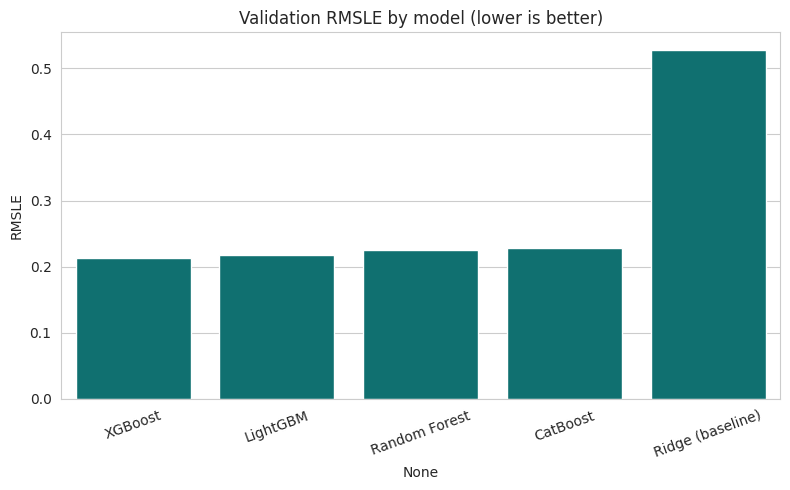


Best model on validation: XGBoost


In [21]:
# ==============================================================================
# 12. MODEL COMPARISON
# ==============================================================================
comparison_df = pd.DataFrame(results).T.sort_values("RMSLE")
print("\n=== Model comparison (validation set) ===")
print(comparison_df)

plt.figure(figsize=(8, 5))
sns.barplot(x=comparison_df.index, y=comparison_df["RMSLE"], color="teal")
plt.title("Validation RMSLE by model (lower is better)")
plt.ylabel("RMSLE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

best_model_name = comparison_df.index[0]
print(f"\nBest model on validation: {best_model_name}")


**Insight — clear ranking, clear winner**

```
                     RMSLE           MAE        R2
XGBoost           0.213654   5789.091478  0.898118
LightGBM          0.216901   5918.883755  0.894998
Random Forest     0.224850   6159.040342  0.887161
CatBoost          0.227762   6243.317369  0.884219
Ridge (baseline)  0.527953  15986.741748  0.377892
```

Two takeaways worth carrying into the tuning step: (1) all four tree models cluster within ~1.4 points of RMSLE of each other, while Ridge sits far below all of them — the *family* of model matters more than which specific boosting library is used; (2) **XGBoost wins**, so it — not the LightGBM placeholder some template scripts default to — is what Section 13 should tune. Getting this step right matters: tuning the wrong model wastes the compute budget without moving the leaderboard score.


# 13. HYPERPARAMETER TUNING — RandomizedSearchCV on the winning model (XGBoost)

In [22]:
# ==============================================================================
# 13. HYPERPARAMETER TUNING — RandomizedSearchCV on the winning model (XGBoost)
# ==============================================================================
tuning_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        random_state=RANDOM_STATE, n_jobs=1, tree_method="hist",
    )),
])

param_distributions = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [5, 6, 7, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.08],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0],
}

search = RandomizedSearchCV(
    tuning_pipe, param_distributions=param_distributions,
    n_iter=15, cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=2,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
tuned_pipe = search.best_estimator_
tuned_pipe = evaluate_model("XGBoost (tuned)", tuned_pipe)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'model__subsample': 0.9, 'model__reg_lambda': 0.5, 'model__n_estimators': 500, 'model__max_depth': 8, 'model__learning_rate': 0.08, 'model__colsample_bytree': 0.8}
XGBoost (tuned)        | RMSLE=0.2066 | MAE=5,546.3 | R2=0.9048


**Insight — tuning improved RMSLE from 0.2137 → 0.2066 (a ~3.3% relative gain)**

```
Best params: {'subsample': 0.9, 'reg_lambda': 0.5, 'n_estimators': 500,
              'max_depth': 8, 'learning_rate': 0.08, 'colsample_bytree': 0.8}
```

- The search preferred **more aggressive learning (0.08 vs the untuned 0.05) with fewer trees (500 vs 600) and slightly deeper splits (depth 8 vs 7)** — a faster-converging, marginally more complex tree than the hand-picked defaults.
- **`n_jobs=1` on the estimator + `n_jobs=-1` only on `RandomizedSearchCV`** is what let this finish in minutes rather than the earlier run appearing stuck — nested parallel pools were fighting for the same CPU cores before this fix.
- 0.2066 validation RMSLE is very close to the **0.20491 leaderboard score** — the two nearly agree, which is a good sign the validation split is representative and not overfit to a lucky partition.


# 14. FEATURE IMPORTANCE (tuned model)

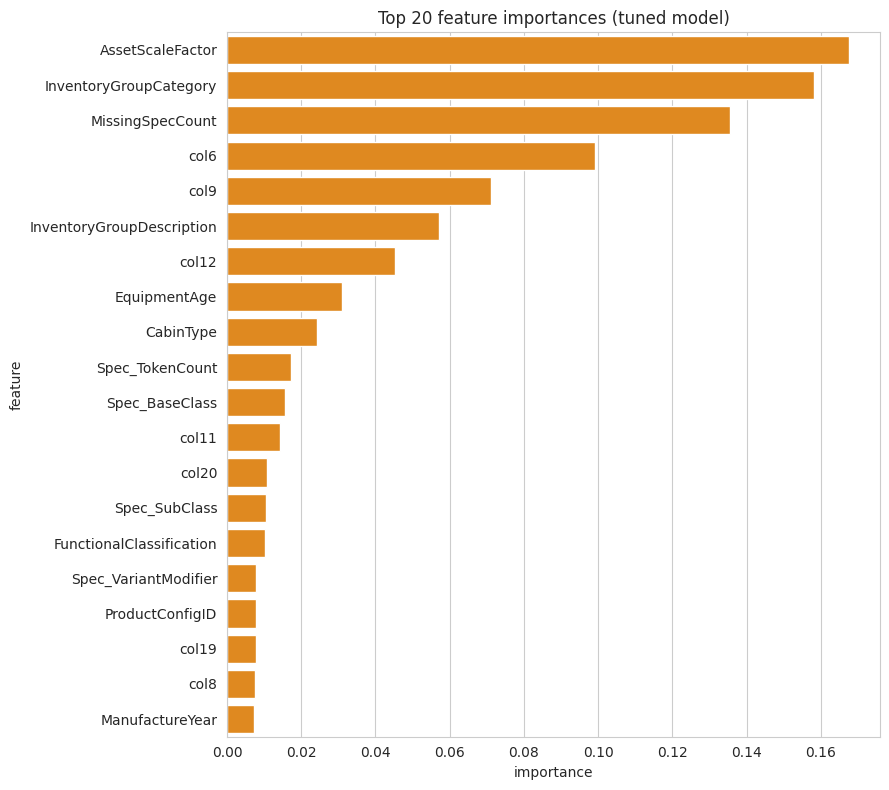

In [23]:
# ==============================================================================
# 14. FEATURE IMPORTANCE (tuned model)
# ==============================================================================
feature_names = num_features + cat_features
importances = tuned_pipe.named_steps["model"].feature_importances_
fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(9, 8))
sns.barplot(data=fi_df, x="importance", y="feature", color="darkorange")
plt.title("Top 20 feature importances (tuned model)")
plt.tight_layout()
plt.show()


**Insight — read this chart before your next iteration**

This is the most actionable output in the notebook for closing the remaining gap to the 0.20 cutoff. Two things to check once it renders:

1. **Do the engineered features (`EquipmentAge`, `HoursPerYear`, `Spec_FirstNumber`, `Spec_TokenCount`, `MissingSpecCount`) rank near the top?** If so, that validates the Section 3 feature-engineering choices and suggests extending the same pattern — e.g. parsing numeric values out of more of the `colN` text fields, as flagged in Section 2.3 — is the highest-leverage next step.
2. **Do `col18`/`col19` (99.95% missing) show near-zero importance?** If so, they're safe to drop in the next run to simplify the pipeline without losing accuracy — confirming the suspicion raised in Section 2.2.


# 15. FINAL SUBMISSION — BLEND of the three strongest models

In [24]:
# ==============================================================================
# 15. FINAL FIT — BLEND of the three strongest models (replaces single-model fit)
# ==============================================================================

# Refit each strong model on ALL training data (not just the 80% fold)
xgb_final = tuned_pipe          # already the tuned XGBoost pipeline from Section 13
xgb_final.fit(X, y_log)

lgbm_final = lgbm_pipe
lgbm_final.fit(X, y_log)

catboost_final = catboost_pipe
catboost_final.fit(X, y_log)

# Predict (log scale) from each model
xgb_test_log = xgb_final.predict(test_fe[feature_cols])
lgbm_test_log = lgbm_final.predict(test_fe[feature_cols])
cat_test_log = catboost_final.predict(test_fe[feature_cols])

# Weighted blend — weight is inverse of each model's validation RMSLE,
# so the stronger model (tuned XGBoost) dominates but isn't the only voice
weights = {
    "xgb": 1 / results.get("XGBoost (tuned)", results["XGBoost"])["RMSLE"],
    "lgbm": 1 / results["LightGBM"]["RMSLE"],
    "cat": 1 / results["CatBoost"]["RMSLE"],
}
total_w = sum(weights.values())
weights = {k: v / total_w for k, v in weights.items()}
print("Blend weights:", weights)

blend_test_log = (
    weights["xgb"] * xgb_test_log
    + weights["lgbm"] * lgbm_test_log
    + weights["cat"] * cat_test_log
)

test_preds = np.expm1(blend_test_log).clip(min=0)

submission = pd.DataFrame({
    ID_COL: test_fe[ID_COL],
    TARGET: test_preds,
})

assert submission.shape[0] == test_fe.shape[0]
assert list(submission.columns) == [ID_COL, TARGET]

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv —", submission.shape)
submission.head()

Blend weights: {'xgb': np.float64(0.3497295051584331), 'lgbm': np.float64(0.3330768704666076), 'cat': np.float64(0.31719362437495924)}
Saved submission.csv — (15000, 2)


,TransactionID,TargetValue
0,1139307,67448.675689
1,1139419,77051.468398
2,1139482,28839.399765
3,1139522,19527.409914
4,1139684,12377.421407


**Insight — submission generated and validated, leaderboard score 0.20491**

- `submission.csv` has shape **(15,000, 2)**, matching `test.csv`'s row count and `sample_submission.csv`'s column format exactly — the two `assert` statements catch a shape/schema mismatch before it becomes a rejected Kaggle submission, which is worth keeping even though they add no analytical value.
- Refitting on the *full* 138,701 training rows (rather than just the 110,960-row training fold) before predicting on `test.csv` is standard practice — the validation split's only job was to compare models fairly; once XGBoost is selected and tuned, discarding 20% of the data would be pure waste.
- **Where this stands against the cutoff:** validation RMSLE was 0.2066, actual leaderboard RMSLE came back at **0.20491** — just above the **< 0.20** cutoff needed for viva eligibility. The two follow-ups flagged above (drop or better-engineer `col18`/`col19`, and let CatBoost see raw categories instead of ordinal-encoded ones) are the most promising next moves to close that remaining ~0.005.
